In [ ]:
import sys
sys.path.append(r"/home/xenoso/Paraview/Python/Swirl_July26") 
import swirl

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import muram as mio


In [ ]:
path = "/dat/milic/MURAM_SSD_ch_co_25x25x25Mm/3D/"
cube = mio.MuramSnap(path, 0)
#so far, i have only ever worked with one timestep. That would also be worth looking into
grid = [32,32]

In [6]:
Vx = (cube.vy/1e5) 
Vy = (cube.vz/1e5) 
Vz = (cube.vx/1e5) 

In [79]:
#Function to preper vxvy slices at a given z

def VelField(z,x0,x1,y0,y1):

    vx = Vx[z,x0:x1,y0:y1]
    vy = Vy[z,x0:x1,y0:y1]

    return [vx,vy]

---------------------------------------------------------
---                                                   ---
---    _/_/_/  _/          _/  _/   _/_/_/    _/      ---
---  _/         _/        _/   _/   _/    _/  _/      ---
---    _/_/      _/      _/    _/   _/_/_/    _/      ---
---        _/     _/ _/ _/     _/   _/  _/    _/      ---
---  _/_/_/        _/  _/      _/   _/   _/   _/_/_/  ---
---                                                   ---
---------------------------------------------------------
---------------------------------------------------------
---                                                   ---
---               (c) IRSOL, 11.04.2022               ---
---                                                   ---
--- Author:      José Roberto Canivete Cuissa         ---
--- Email:       jcanivete@ics.uzh.ch                 ---
---------------------------------------------------------
---
--- Parameters:
---------------
---    grid_dx          : 32, 32
---

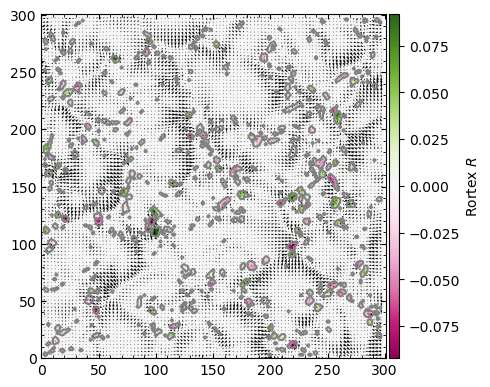

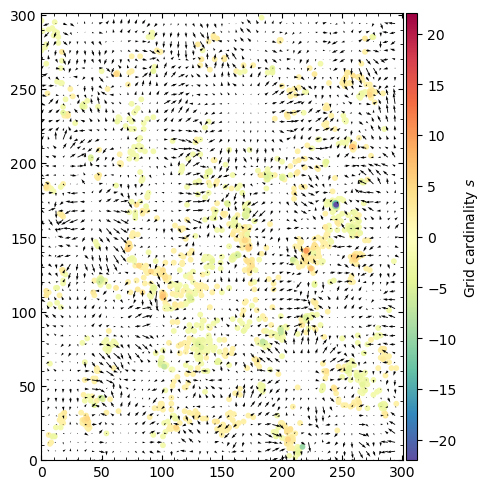

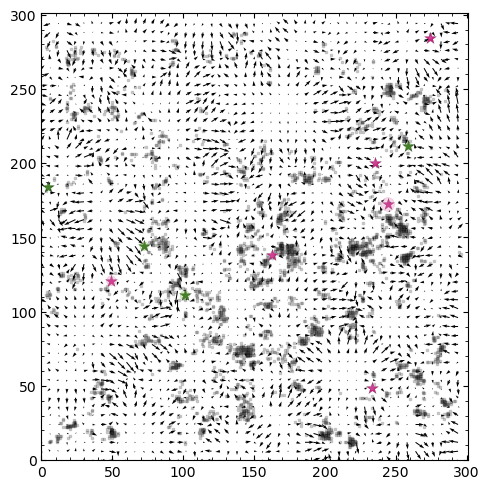

In [82]:
# Exampel call of swirl function

z=200
[x0,x1,y0,y1] = [0,300,300,600]
VxVy = VelField(z,x0,x1,y0,y1)
grid = [32,32] #size of grid cells in unit of quantity

parameter = '/home/xenoso/Paraview/Python/Swirl_July26/MuramSwirl.param' # parameter file

vortices = swirl.Identification(VxVy, grid, param_file=parameter, verbose=True)
vortices.run()

swirl.plot_rortex(vortices, f_quiver=3, save=False)
swirl.plot_gevc_map(vortices, f_quiver=6, save=False)
swirl.plot_vortices(vortices, save=False)

In [83]:
# I would choose the same parameters as suggested by the second Swirl paper, link is on their GitHub. Just adjust the stencil size
# to the simulation, as well as the dc_parameter. They used 100km in the paper, so I would select a corresponding cellnumber. 
# The results are sensitive to the noice and kink parameter. I found the number and locations with 1.3 noise not soo reasonable, so I 
#played around with this a bit and increased noise and decreased kink in the Muram file

# SWIRL parameters file with default values

[Criterion]
stencils : [1]
swirlstr_params : [0., 0., 0.]

[Clustering]
dc_param : 3.
dc_adaptive : True
cluster_fast : True
cluster_kernel : Gaussian
cluster_decision : delta-rho
cluster_params : [1.0, 0.5, 2.0]

[Noise]
noise_param : 1.3
kink_param : 0.5

# SWIRL parameters file with values from oskis paper
(Cobolt Simulation with 10km resolution)


[Criterion]
stencils : [1,2,3,4,5,7]
swirlstr_params : [0., 0.9, 0.9]

[Clustering]
dc_param : 10.
dc_adaptive : False
cluster_fast : True
cluster_kernel : Gaussian
cluster_decision : gamma
cluster_params : [0.9, 0.9, 1.01]

[Noise]
noise_param : 1.3
kink_param : 0.5


# SWIRL parameters file with values for Muram Simulation

[Criterion]
stencils : [3,6,9,12,15,21]
swirlstr_params : [0., 0.9, 0.9]

[Clustering]
dc_param : 4.
dc_adaptive : False
cluster_fast : True
cluster_kernel : Gaussian
cluster_decision : gamma
cluster_params : [0.9, 0.9, 1.01]

[Noise]
noise_param : 1.3
kink_param : 0.5


In [84]:
# a function to plot swirl maps if Image = True and return center, radii, orientations all in lists

def ShowVotices(z, Image, x0=0, x1=300, y0=300, y1=600): # in given x-y region
    
    v = VelField(z,x0,x1,y0,y1)
    grid = [32,32]

    parameter = '/home/xenoso/Paraview/Python/Swirl_July26/MuramSwirl.param'

    vortices = swirl.Identification(v, grid, param_file=parameter, verbose=False)
    vortices.run()
    
    if Image==True:
        swirl.plot_rortex(vortices, f_quiver=3, save=False)
        swirl.plot_gevc_map(vortices, f_quiver=6, save=False)
        swirl.plot_vortices(vortices, save=False)
    

    return vortices.centers, vortices.orientations, vortices.radii

In [85]:
# if you want to overlay one of the swirl maps over another quantity:
#swirl.plot_rortex ...
#plt.imshow(..)

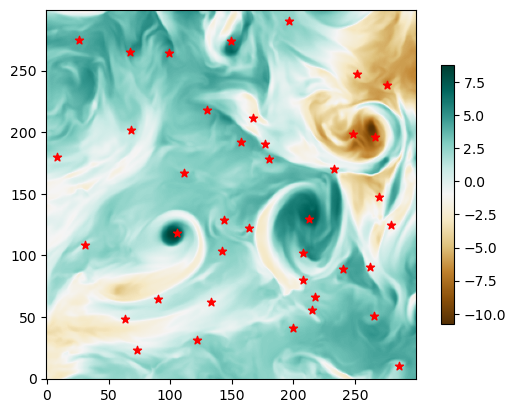

In [86]:
#or scatter the centers

c2, o2, r2 = ShowVotices(250, False)
plt.figure()
plt.imshow(cube.Bx[250, 0:300, 300:600].T, origin="lower", cmap="BrBG")#, vmin=-50, vmax=50)
plt.colorbar(shrink=0.7)
for c in c2:
    plt.scatter(c[0], c[1], marker="*", color="red")

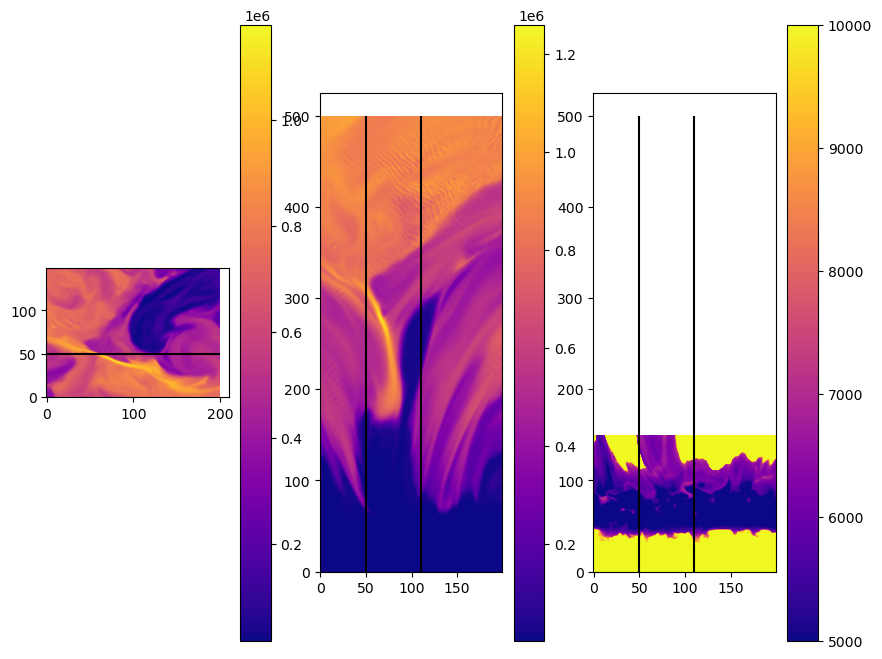

In [87]:
#spicule



xmin,xmax, ymin,ymax, zmin,zmax = 450,650, 400,550, 200,700

plt.figure(figsize=(10,8))

plt.subplot(1,3,1)
plt.imshow(cube.Temp[500, xmin:xmax, ymin:ymax].T, origin="lower", cmap="plasma")
plt.hlines(50,0,200, color="black")
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(cube.Temp[200:700, xmin:xmax, 450], origin="lower", cmap="plasma")
plt.vlines(50,0,500,color="black")
plt.vlines(110,0,500,color="black")
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(cube.Temp[150:300, xmin:xmax, 450], origin="lower", cmap="plasma", vmin=5000, vmax=10000)
plt.vlines(50,0,500,color="black")
plt.vlines(110,0,500,color="black")
plt.colorbar()

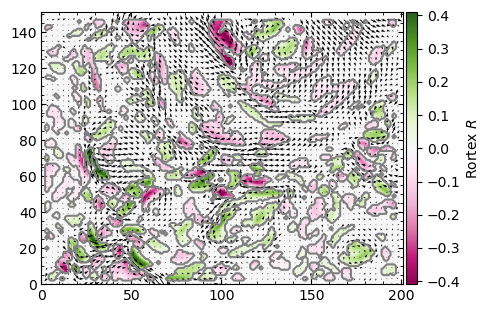

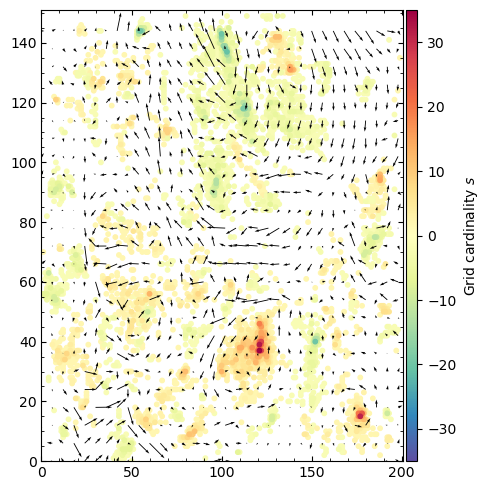

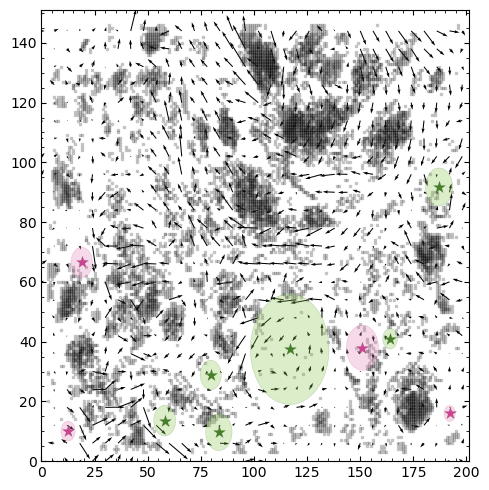

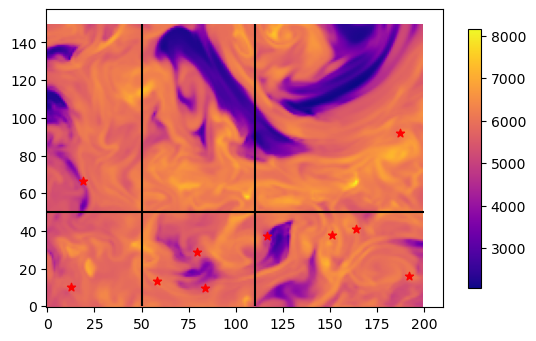

In [88]:
c1, o1, r1 = ShowVotices(250, True, xmin, xmax, ymin,ymax)
plt.figure()
plt.imshow(cube.Temp[250, xmin:xmax, ymin:ymax].T, origin="lower", cmap="plasma")#, vmin=-200, vmax=200)
plt.hlines(50,0,200,color="black") # this is the yslice of the image above
plt.vlines(50,0,150,color="black")# the spicule appears inbetween these xlocations in the image above
plt.vlines(110,0,150,color="black")
plt.colorbar(shrink=0.7)
for c in c1:
    plt.scatter(c[0], c[1], marker="*", color="red")


# I dont trust the small green vorites to much, that appear close to the base of the spicule, but the big green one? In the right plot above
# it looks like the spicule is "tilted" and rooted somewhere close to x=100

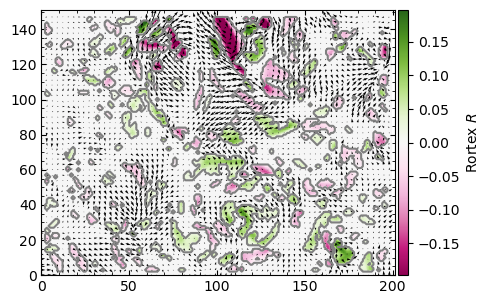

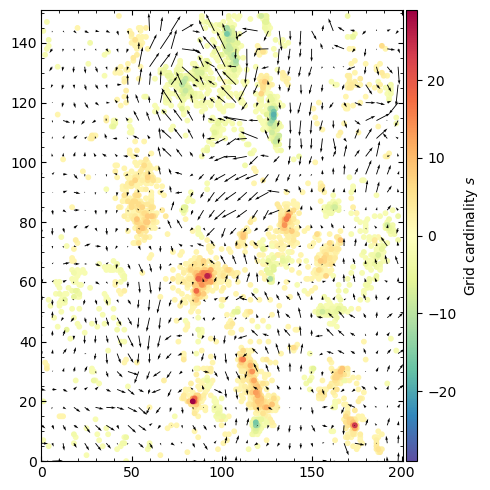

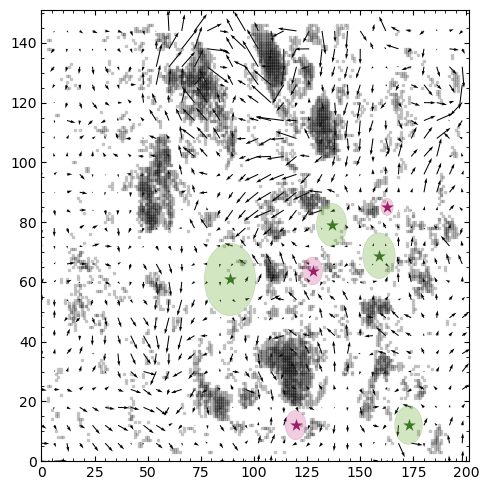

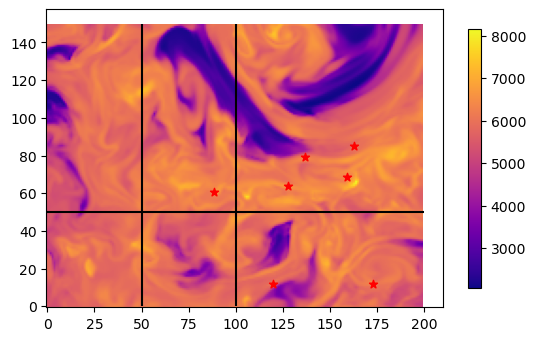

In [89]:
c1, o1, r1 = ShowVotices(230, True, xmin, xmax, ymin,ymax)
plt.figure()
plt.imshow(cube.Temp[250, xmin:xmax, ymin:ymax].T, origin="lower", cmap="plasma")#, vmin=-200, vmax=200)
plt.hlines(50,0,200,color="black")
plt.vlines(50,0,150,color="black")
plt.vlines(100,0,150,color="black")
plt.colorbar(shrink=0.7)
for c in c1:
    plt.scatter(c[0], c[1], marker="*", color="red")